# Manifold learning (_Swiss Roll_)

In [1]:
from experiments.utils.constants import RANDOM_SEED, SOM_LEARNING_RATE_DECAY_FN, SOM_FIT_METHOD

VERBOSE = True
MANIFOLD_NAME = "Swiss Roll"
MODELING_MODE = False
MODEL_REGISTRATION_MODE = False
EXPORT_MODE = False
EXPORT_DIR = "_exports"

from experiments.utils.data_manifold import generate_swiss_roll
MANIFOLD_GENERATOR = generate_swiss_roll

## Dataset

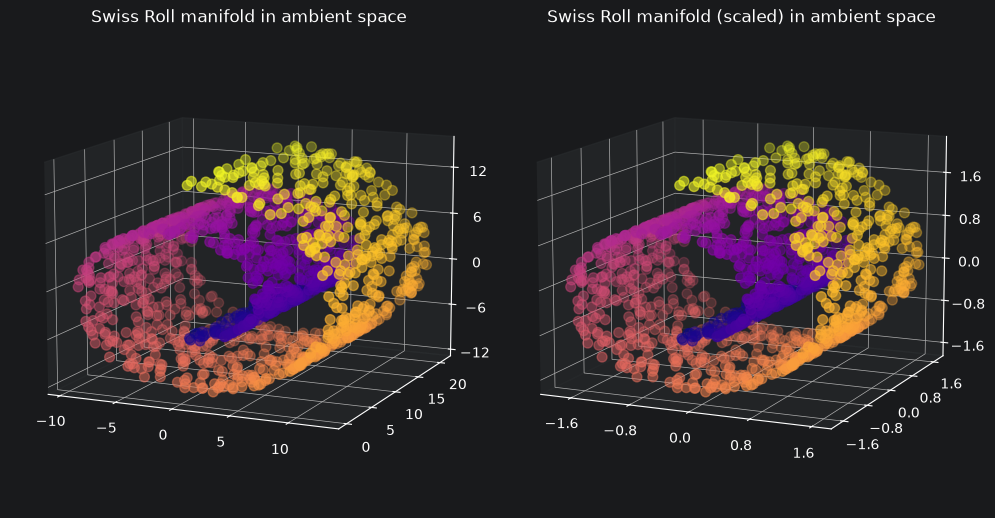

In [2]:
# generate data
from experiments.utils.plotting import visualize_manifold
X, y = MANIFOLD_GENERATOR()

# visualize 1/2
import matplotlib.pyplot as plt
figMan1 = plt.figure(figsize=(10, 10))
ax0 = figMan1.add_subplot(121, projection="3d")
visualize_manifold(X, y, title=f"{MANIFOLD_NAME} manifold in ambient space", ax=ax0, hold_on=True);

# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
del X

# visualize 2/2
ax1 = figMan1.add_subplot(122, projection="3d")
visualize_manifold(X_scaled, y, title=f"{MANIFOLD_NAME} manifold (scaled) in ambient space", ax=ax1, hold_on=False);

## Modeling

In [3]:
from minisom_representation import calc_som_hyparams, SomRepresentation, plot_som_convergence_over_epochs

In [4]:
# use helper methods to get SOM hyperparameter recommendations
recommended_params = calc_som_hyparams(X_scaled, initial_sigma_factor=3.0)
print("Recommended SOM parameters:", recommended_params)

Recommended SOM parameters: {'d1': 14, 'd2': 15, 'sigma': 5.0}


In [5]:
# define actual hyperparameters
d1, d2, sigma = map(recommended_params.get, ("d1", "d2", "sigma"))
decay_function = SOM_LEARNING_RATE_DECAY_FN
epoch = None

In [6]:
# test candidate values for `num_iteration` hyperparameter
if MODELING_MODE:
    fig, errors_qe, errors_te = plot_som_convergence_over_epochs(
        SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=False, decay_function=decay_function),
        X_scaled,
        fit_type=SOM_FIT_METHOD, te_ceiling=.1,
        epoch_step_from=2, epoch_step_to=50, epoch_step=1,
        figsize=(16, 5), show_fig=True, verbose=VERBOSE
    )
    print(f"\nQE (first -> last): \t {errors_qe[0]:.2f} -> {errors_qe[-1]:.2f}")
    print(f"TE (first -> last): \t {errors_te[0]:.2f} -> {errors_te[-1]:.2f}")
else: print("Skipping model candidate parameters evaluation.")

Skipping model candidate parameters evaluation.


In [7]:
# set selected `num_iteration` as epoch
epoch = 42

In [8]:
# fit SOM representation
som_rep = SomRepresentation(d1=d1, d2=d2, sigma=sigma, random_seed=RANDOM_SEED, verbose=VERBOSE, decay_function=decay_function) \
    .fit_online(X_scaled, num_iteration=epoch)

 [ 63000 / 63000 ] 100% - 0:00:00 left 
 quantization error: 0.4365402959102238

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Fit strategy: online 

Hyperparameters of SOM: 

{'input_len': 3, 'x': 14, 'y': 15, 'sigma': 5.0, 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'linear_decay_to_zero', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 42, 'use_epochs': True, 'random_order': True, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	0.4365402959102238
Topographic Error (TE): 	0.004666666666666667


## Direct inspection of the fitted representation model

In [9]:
# extract SOM prototype weights
som = som_rep.som
node_weights = som.get_weights()
node_weights_flat = node_weights.reshape(-1, node_weights.shape[2])

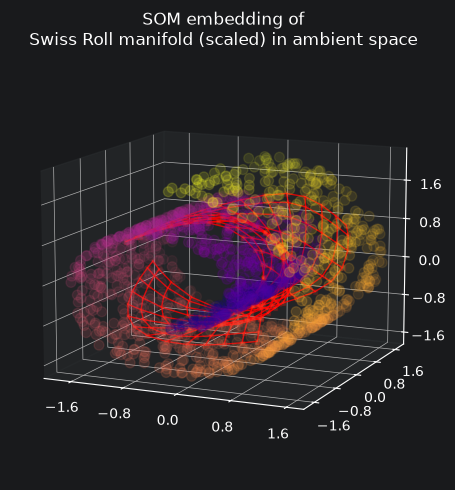

In [10]:
from utils.plotting import place_som_lattice
data_plot_style = { "alpha": 0.45 }
figMan2, ax = visualize_manifold(X_scaled, y, f"SOM embedding of\n{MANIFOLD_NAME} manifold (scaled) in ambient space", plot_style_args=data_plot_style, hold_on=True)
place_som_lattice(ax, node_weights, node_weights_flat)

In [11]:
if EXPORT_MODE:
	figMan1.savefig(EXPORT_DIR + "/01_03_lilypond_manifold_01.png")
	figMan2.savefig(EXPORT_DIR + "/01_03_lilypond_manifold_02.png")

## Inspection of the learned 2D topology

In [12]:
from utils.plotting import PlotlyHelperArgs

In [13]:
# create Basin
from lilypond import Basin
basin = Basin.from_som_representation(som_rep, random_seed=RANDOM_SEED, verbose=VERBOSE)

In [14]:
# export basin
if EXPORT_MODE:
	from utils.export import BasinWithTrainingData
	BasinWithTrainingData(dataset_name=MANIFOLD_NAME, basin=basin, X_train=X_scaled).export(EXPORT_DIR + "/other")

In [15]:
# traditional visuals
plot_args = dict(
    **PlotlyHelperArgs.FullStretch,
    **PlotlyHelperArgs.HiddenTicks(d1=d1, d2=d2),
    font=dict(size=35),
    title="",
)
figTrad1 = basin.legacy_pond().visualize_distance_map(**plot_args, **PlotlyHelperArgs.Figsize(w=950, h=600));
figTrad2 = basin.legacy_pond().visualize_activation_map(**plot_args, **PlotlyHelperArgs.Figsize(w=850, h=600));

In [16]:
if EXPORT_MODE:
	figTrad1.write_image(EXPORT_DIR + "/01_03_lilypond_trad_01.png")
	figTrad2.write_image(EXPORT_DIR + "/01_03_lilypond_trad_02.png")

In [17]:
# lilypond visual
basin.pond() \
    .rhizome_layer() \
    .pad_layer() \
    .petal_layer() \
    .visualize(width=800, height=600);

## Detailed inspection

In [18]:
plot_args = dict(
    **PlotlyHelperArgs.Figsize(w=400, h=400),
    **PlotlyHelperArgs.FullStretch,
    **PlotlyHelperArgs.HiddenTicks(d1=d1, d2=d2),
    font=dict(size=35),
    showlegend=False
)

In [19]:
fig1 = basin.pond() \
    .pad_layer() \
    .visualize(**plot_args);

In [20]:
fig2 = basin.pond() \
    .pad_layer(gap="nogap") \
    .visualize(**plot_args);

In [21]:
fig3 = basin.pond() \
    .pad_layer(gap="nogap") \
    .petal_layer() \
    .visualize(**plot_args);

In [22]:
fig4 = basin.pond() \
    .pad_layer(gap="nogap") \
    .rhizome_layer() \
    .attraction_layer(X_scaled, marker=dict(color=y, colorscale="plasma", symbol="star-diamond", opacity=.8), name="Projection of training data colored by Manifold position") \
    .visualize(**plot_args);

In [23]:
fig5 = basin.pond() \
    .pad_layer(gap="nogap") \
    .rhizome_layer(violations_only=True) \
    .attraction_layer(X_scaled, marker=dict(color=y, colorscale="plasma", symbol="star-diamond", opacity=.8), name="Projection of training data colored by Manifold position") \
    .visualize(**plot_args);

In [24]:
if EXPORT_MODE:
	fig1.write_image(EXPORT_DIR + "/01_03_lilypond_01.png")
	fig2.write_image(EXPORT_DIR + "/01_03_lilypond_02.png")
	fig3.write_image(EXPORT_DIR + "/01_03_lilypond_03.png")
	fig4.write_image(EXPORT_DIR + "/01_03_lilypond_04.png")
	fig5.write_image(EXPORT_DIR + "/01_03_lilypond_05.png")

---

### The below cells are not part of the experiment. They are used to register the model in Databricks and Bianor for further interactive investigation.

---

## Register representation model in Databricks

In [25]:
from dotenv import load_dotenv
load_dotenv()

True

In [28]:
CATALOG = "workspace"
SCHEMA = "lilypond_experiments"
MODEL_NAME = f"som-{MANIFOLD_NAME.lower().replace(' ', '-')}"
MODEL_PATH = f"{CATALOG}.{SCHEMA}.{MODEL_NAME}"
EXPERIMENT_NAME = f"/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_{MANIFOLD_NAME.replace(' ', '_')}"
print(MODEL_PATH, EXPERIMENT_NAME)

workspace.lilypond_experiments.som-swiss-roll /Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_Swiss_Roll


In [29]:
import mlflow
import pandas as pd
from typing import Any

mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

class MLflowSomModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model:SomRepresentation, scaler):
        self.model = model
        self.scaler = scaler
    def predict(self, context, model_input, params: dict[str, Any] | None = None):
        """First transforms the input data via scaler, then predicts the winner node of the SOM."""
        return [self.model.som.winner(x) for x in self.scaler.transform(model_input.to_numpy())]

if MODEL_REGISTRATION_MODE:
    with mlflow.start_run():
        model = MLflowSomModelWrapper(som_rep, scaler)

        mlflow.log_metric("QE", som_rep.quantization_error)
        mlflow.log_metric("TE", som_rep.topographic_error)

        mlflow.pyfunc.log_model(
            python_model=model,
            name=MODEL_NAME,
            input_example=pd.DataFrame(X_scaled[:3]),
            pip_requirements=[
                "numpy",
                "pandas",
                "scikit-learn==1.5.2",
                "mlflow",
                "minisom",
            ],
            registered_model_name=MODEL_PATH
        )
else: print("Skipping MLflow model registration.")

2026/09/13 01:56:26 INFO mlflow.tracking.fluent: Experiment with name '/Users/matebalogh@ophelia-rnd.dev/Bianor_LilypondExperiments_Swiss_Roll' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog
/opt/homebrew/Caskroom/miniconda/base/envs/wsom-lilypond-exp/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/09/13 01:56:38 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using 

🏃 View run thoughtful-foal-342 at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/2251809713951654/runs/08eaeff3b87f4013b3a0084b75f82656
🧪 View experiment at: dbc-ca44ccd5-3843.cloud.databricks.com/ml/experiments/2251809713951654


In [30]:
version = 1
registered_model = f"{MODEL_NAME}/{version}"
registered_model

'som-swiss-roll/1'

## Register metadata in Bianor

In [31]:
from databricks.connect import DatabricksSession
spark = DatabricksSession.builder.getOrCreate()

In [32]:
from bianor_databricks_kit import BianorRecordManager
bianor_recorder = BianorRecordManager(catalog=CATALOG, schema=SCHEMA, spark=spark)

In [33]:
registered_model_location = f"{CATALOG}.{SCHEMA}.{registered_model}"
registered_model_location

'workspace.lilypond_experiments.som-swiss-roll/1'

In [34]:
if MODEL_REGISTRATION_MODE:
    bianor_recorder.new_representation(name=f"{MANIFOLD_NAME} Manifold", som_model_location=registered_model_location, features_location="c.s.t") # FIXME
else: print("Skipping Bianor metadata registration.")